# Multiclass IMV — Car Evaluation

One-vs-rest IMV and the pairwise IMV matrix on the UCI Car Evaluation dataset
(four classes: unacc, acc, good, vgood).

This dataset has **no counterpart in the original notebooks** — the published
figure's Car Evaluation panel was a hardcoded literal whose generating code was
never preserved. These are therefore new results, not a replication.

The `good`/`vgood` pair holds only 134 of 1728 rows, so that cell of the matrix is
the least stable; treat it with the seed spread in view.

**Pipeline**: download from UCI → ordinal-encode → 10 seeds × 3 estimators →
aggregate.

Full documentation: `documentation/examples/multi_imv/car_evaluation.md`.

In [1]:
import os, sys, tempfile, warnings, itertools
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "multi_imv_car_evaluation"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES = ARTIFACTS / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)

# Ten seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over ten independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_SPLITS = 5

import imv
from imv import MulticlassIMV
from imv.utils import save_figure

# Fail fast if Jupyter is attached to a different installation of imv.
_HERE = Path().resolve()
REPOSITORY_ROOT = next((path for path in (_HERE, *_HERE.parents)
                        if (path / "pyproject.toml").is_file()
                        and (path / "src" / "imv").is_dir()), None)
if REPOSITORY_ROOT is None:
    raise RuntimeError("Run this notebook from inside the imv repository checkout.")
_PATH_DISPLAY_ROOT = REPOSITORY_ROOT
IMV_SOURCE = Path(imv.__file__).resolve().parent
EXPECTED_IMV_SOURCE = (REPOSITORY_ROOT / "src" / "imv").resolve()
if IMV_SOURCE != EXPECTED_IMV_SOURCE:
    raise RuntimeError("Expected repository package at "
                       f"{relative_path(EXPECTED_IMV_SOURCE)}, imported "
                       f"{relative_path(IMV_SOURCE)}")
print(f"imv {imv.__version__} from {relative_path(IMV_SOURCE)}")


imv 1.2.0 from src/imv


## 1. Download

Nothing is read from the repository.

In [2]:
from ucimlrepo import fetch_ucirepo
DATASET, TITLE = "car_evaluation", "Car Evaluation"
raw = fetch_ucirepo(id=19)
frame = raw.data.features.copy()
frame["target_raw"] = raw.data.targets.iloc[:, 0].astype(str).str.strip()
print(frame.shape); print(frame["target_raw"].value_counts().to_dict())
frame.head()

(1728, 7)
{'unacc': 1210, 'acc': 384, 'good': 69, 'vgood': 65}


,buying,maint,doors,persons,lug_boot,safety,target_raw
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## 2. Preprocess

In [3]:
CLASS_NAMES = ["unacc", "acc", "good", "vgood"]
frame["target"] = frame["target_raw"].map({n: i for i, n in enumerate(CLASS_NAMES)})
FEATURES = [c for c in frame.columns if c not in ("target", "target_raw")]
for column in FEATURES:
    frame[column] = pd.Categorical(frame[column].astype(str)).codes
data = frame[FEATURES + ["target"]].dropna()
data["target"] = data["target"].astype(int)
print(data.shape, FEATURES); print(data["target"].value_counts().sort_index().to_dict())
data.head()

(1728, 7) ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
{0: 1210, 1: 384, 2: 69, 3: 65}


,buying,maint,doors,persons,lug_boot,safety,target
0,3,3,0,0,2,1,0
1,3,3,0,0,2,2,0
2,3,3,0,0,2,0,0
3,3,3,0,0,1,1,0
4,3,3,0,0,1,2,0


## 3. Estimators

In [4]:
def model_factories(seed):
    """Three estimator families, deliberately small so the exact power set is affordable."""
    return {
        "logistic_regression": lambda: LogisticRegression(max_iter=5000, random_state=seed),
        "xgboost": lambda: XGBClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbosity=0, tree_method="hist", n_jobs=1),
        "lightgbm": lambda: LGBMClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbose=-1, n_jobs=1),
    }


## 4. One-vs-rest and pairwise IMV over ten seeds

Stratified folds are used so no fold can omit a class; the evaluator passes `model.classes_` through, so probability columns are matched to labels rather than to fold position.

In [5]:
ova_records, matrices = [], {}
for seed in SEEDS:
    frame = data.reset_index(drop=True)
    for name, factory in model_factories(seed).items():
        evaluator = MulticlassIMV(
            frame, "target", factory, n_splits=N_SPLITS,
            optional_explanatory_variables=FEATURES,
            random_state=seed, stratified=True,
        )
        _, ova_mean = evaluator.k_fold_one_vs_all()
        _, matrix_mean = evaluator.k_fold_imv_matrix()
        for label, value in zip(matrix_mean.index, ova_mean):
            ova_records.append({"seed": seed, "model": name,
                                "class": label, "one_vs_rest_imv": value})
        matrices.setdefault(name, []).append(matrix_mean)

ova = pd.DataFrame(ova_records)
ova.to_csv(RESULTS / f"{DATASET}_one_vs_rest_by_seed.csv", index=False)
mean_matrices = {name: sum(ms) / len(ms) for name, ms in matrices.items()}
for name, matrix in mean_matrices.items():
    matrix.to_csv(RESULTS / f"{DATASET}_pairwise_imv_{name}.csv")
ova.groupby(["model", "class"])["one_vs_rest_imv"].agg(["mean", "std"]).reset_index()


,model,class,mean,std
0,lightgbm,0,0.415367,0.000806
1,lightgbm,1,0.267769,0.000430
2,lightgbm,2,0.037167,0.000340
3,lightgbm,3,0.037423,0.000147
4,logistic_regression,0,0.147849,0.001206
5,logistic_regression,1,0.046475,0.000881
6,logistic_regression,2,0.003109,0.000427
7,logistic_regression,3,0.019622,0.000184
8,xgboost,0,0.404267,0.000535
9,xgboost,1,0.252004,0.000468


## 5. Figure

The pairwise matrix is **symmetric by construction** — `ll` is invariant under `(y,p) -> (1-y,1-p)` and pairwise renormalisation gives `p_j = 1 - p_i`. Unlike the ablation matrix it carries no directional information.

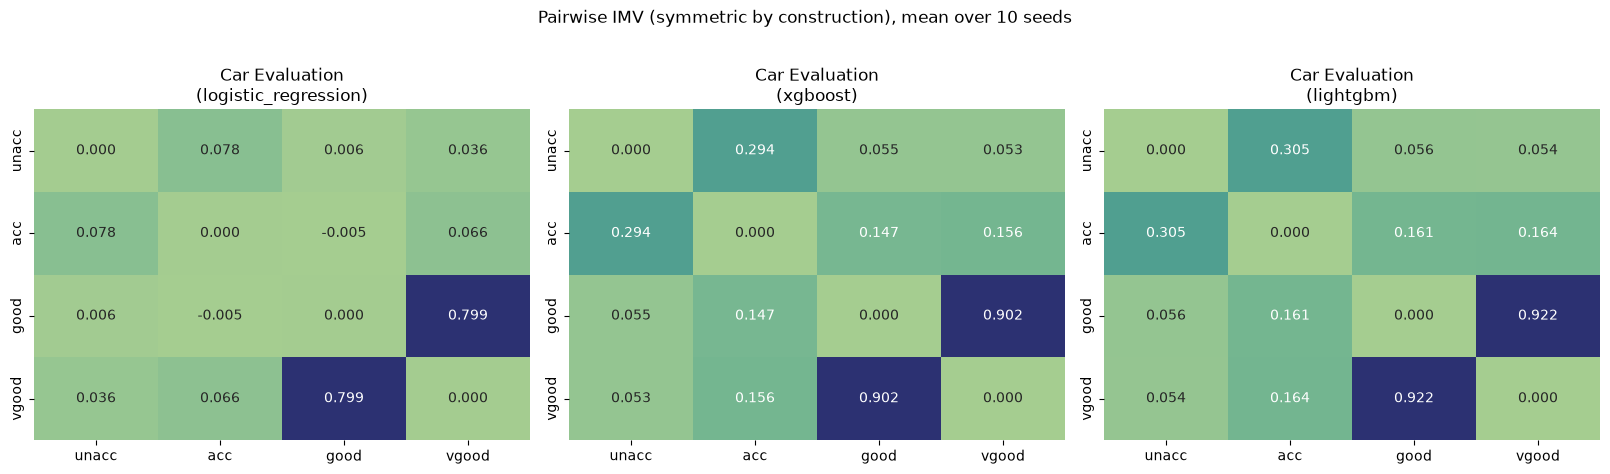

{'png': 'figures/car_evaluation_pairwise_imv.png',
 'pdf': 'figures/car_evaluation_pairwise_imv.pdf',
 'svg': 'figures/car_evaluation_pairwise_imv.svg'}

In [6]:
fig, axes = plt.subplots(1, len(mean_matrices), figsize=(5.4 * len(mean_matrices), 4.6))
axes = np.atleast_1d(axes)
for ax, (name, matrix) in zip(axes, mean_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt=".3f", cmap="crest", cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{TITLE}\n({name})")
fig.suptitle("Pairwise IMV (symmetric by construction), mean over "
             f"{len(SEEDS)} seeds", y=1.02)
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / f"{DATASET}_pairwise_imv"
         ).items()}
plt.show()
paths
